In [63]:
import pandas as pd
import glob

cols = ['open_time','open','high','low','close','volume',
        'close_time','quote_volume','trades','taker_buy_base',
        'taker_buy_quote','ignore']

BASE = '/home/onyxia/work/binance-public-data/python/data/spot/monthly/klines'

def load_symbol(symbol):
    files = sorted(glob.glob(f'{BASE}/{symbol}/1h/**/*.zip', recursive=True))
    print(f"{symbol}: {len(files)} fichiers trouvés")
    dfs = [pd.read_csv(f, names=cols) for f in files]
    df = pd.concat(dfs, ignore_index=True)

    t = pd.to_numeric(df['open_time'], errors='coerce')
    df = df[t.notna()]
    t = t[t.notna()]
    t = (t / 1000).where(t > 1e14, t)
    df['open_time'] = pd.to_datetime(t, unit='ms')

    df = df.set_index('open_time').sort_index()
    return df['close'].astype(float).rename(symbol)

btc = load_symbol('BTCUSDT')
eth = load_symbol('ETHUSDT')
sol = load_symbol('SOLUSDT')

prices = pd.concat([btc, eth, sol], axis=1).dropna().reset_index()
print(prices.shape)

BTCUSDT: 6 fichiers trouvés
ETHUSDT: 6 fichiers trouvés
SOLUSDT: 6 fichiers trouvés
(4344, 4)


In [52]:
prices.head(20)

,open_time,BTCUSDT,ETHUSDT,SOLUSDT,log_BTC,log_ETH,log_SOL,Res of log_BTC on log_ETH,Res of log_BTC on log_SOL,Res of log_ETH on log_BTC,Res of log_ETH on log_SOL,Res of log_SOL on log_BTC,Res of log_SOL on log_ETH
0,2025-01-01 00:00:00,94401.14,3363.70,192.54,11.455308,8.120797,5.260304,-0.110195,-0.065353,0.370280,0.174907,0.198357,-0.088280
1,2025-01-01 01:00:00,93607.74,3346.54,190.70,11.446868,8.115682,5.250702,-0.117205,-0.070986,0.378998,0.179061,0.200300,-0.093941
2,2025-01-01 02:00:00,94098.91,3362.61,191.59,11.452102,8.120473,5.255358,-0.113311,-0.067114,0.375212,0.179357,0.197797,-0.092976
3,2025-01-01 03:00:00,93838.04,3355.20,190.43,11.449326,8.118267,5.249285,-0.115471,-0.068114,0.377555,0.183013,0.195522,-0.097349
4,2025-01-01 04:00:00,93553.91,3341.14,189.47,11.446293,8.114067,5.244231,-0.117329,-0.069669,0.378326,0.183692,0.194616,-0.099167
5,2025-01-01 05:00:00,93792.02,3345.41,190.15,11.448835,8.115345,5.247813,-0.115144,-0.068175,0.375437,0.181511,0.194721,-0.096569
6,2025-01-01 06:00:00,93757.58,3346.60,190.30,11.448468,8.115700,5.248602,-0.115611,-0.068773,0.376395,0.181106,0.196012,-0.096054
7,2025-01-01 07:00:00,93684.10,3347.12,190.06,11.447684,8.115856,5.247340,-0.116438,-0.069188,0.377835,0.182479,0.195823,-0.097436
8,2025-01-01 08:00:00,93428.46,3337.01,189.40,11.444951,8.112830,5.243861,-0.118325,-0.070903,0.379288,0.182812,0.196082,-0.098583
9,2025-01-01 09:00:00,93413.06,3334.64,189.18,11.444786,8.112120,5.242699,-0.118291,-0.070728,0.378848,0.183223,0.195145,-0.099198


In [3]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

Index(['BTCUSDT', 'ETHUSDT', 'SOLUSDT'], dtype='object')


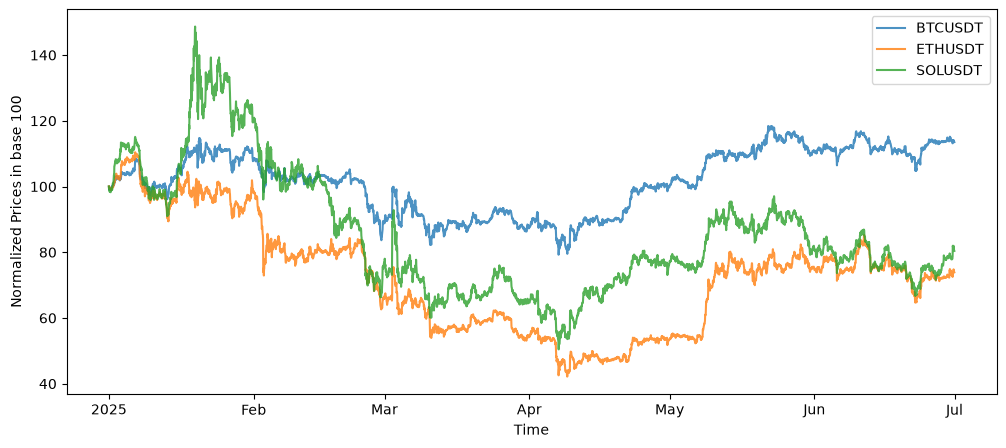

In [65]:
locator = mdates.AutoDateLocator()


fig,ax=plt.subplots(figsize=(12,5))

columns = pd.Series(prices.columns) #On en fait une Série
columns = prices.columns[1:] #On enlève open_time
print(columns)

for col in columns:
    ax.plot(prices['open_time'],
    prices[col]/(prices[col].iloc[0])*100, #To be on the same scale, we compare their evolution, not their level
    label=col,
    alpha=0.8)
ax.set_xlabel("Time")
ax.set_ylabel("Normalized Prices in base 100")
ax.legend()
ax.xaxis.set_major_locator(locator)
ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(locator))
plt.show()
    




In [66]:
import numpy as np

In [67]:
prices["log_BTC"]=np.log(prices['BTCUSDT'])
prices["log_ETH"]=np.log(prices['ETHUSDT'])
prices["log_SOL"]=np.log(prices['SOLUSDT'])

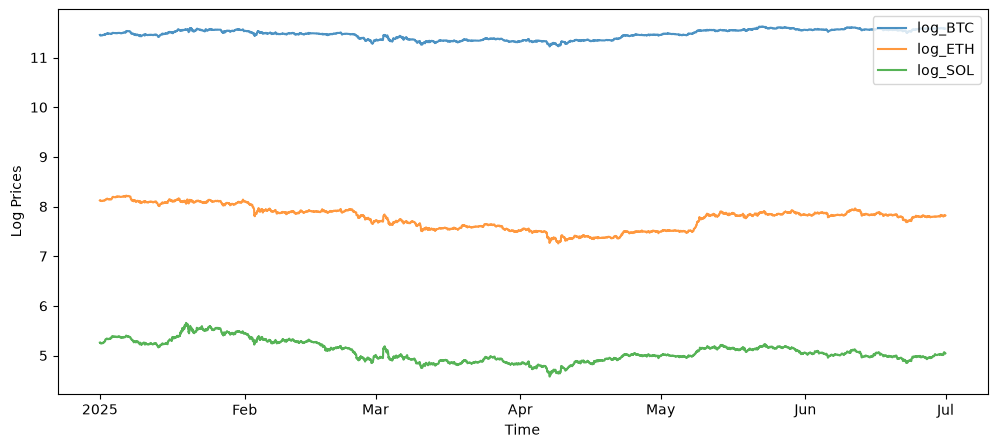

In [68]:
fig,ax=plt.subplots(figsize=(12,5))

for col,color in colors.items():
    ax.plot(prices['open_time'],
    prices[col], #To be on the same scale, we compare their evolution, not their level
    label=col,
    alpha=0.8)
ax.set_xlabel("Time")
ax.set_ylabel("Log Prices")
ax.legend()
ax.xaxis.set_major_locator(locator)
ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(locator))
plt.show()

In [8]:
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller

log_symbols=['log_BTC','log_ETH','log_SOL']
def adf_manuel(log, p):
    dlog = log.diff() #Δlog(X) il va notamment servir pour la variable à prédire, et les lags différenciés, mais c'est pas la composante principale
    X = pd.DataFrame(index=log.index) #Notre tableau des valeurs de log(X)
    X['niveau_lag1'] = log.shift(1) #On ajoute une colonne avec un lag 1 : ie Xt-1, ça sera ce sur quoi on régresse.
    for i in range(1, p + 1):
        X[f'dlog_lag_{i}'] = dlog.shift(i) #Ici on crée les lags différenciés à 'p niveau', Xt-2 - Xt-3 par exemple, Xt-4 - Xt-5
    X['const'] = 1.0 #constante pour notre régression
    reg = pd.concat([dlog.rename('dlog'), X], axis=1).dropna() #concaténation de X et de notre lag différencié (ce qu'on veut prédire)
    res = sm.OLS(reg['dlog'], reg.drop(columns='dlog')).fit() #on fit notre régression : on prédit Δlog(Xt) à l'aide de log(X t-1), Δlog(Xt-1), Δlog(Xt-2)...
    return res.tvalues['niveau_lag1'], res.aic, len(reg) #On demande d'avoir la t_value, uniquement du lag 1, c'est celle qui nous intéresse


for ls in log_symbols:
    aics = {}
    log = prices[ls]
    print(f"\n=== {ls} ===")
    for p in range(1, 16):
        t, aic, n = adf_manuel(log, p) #boucle pour appliquer l'ADF manuel pour différents nombre de lags
        aics[p] = aic #On remplit notre tableau d'AIC (pour pouvoir en tirer l'argmin notamment)
        ref = adfuller(log.dropna(), maxlag=p, autolag=None, regression='c')[0] #On applique directement notre ADF automatique sur les colonnes log du prices[]
        print(f"p={p:2d}  t={t:7.3f}  ref={ref:7.3f}  écart={abs(t-ref):.2e} AIC={aic:.2e} n={n}")
    p_opt = min(aics, key=aics.get)
    print(f'the number of diffs for {ls} that minimizes AIC is {p_opt}')


=== log_BTC ===
p= 1  t= -1.588  ref= -1.588  écart=0.00e+00 AIC=-3.32e+04 n=4342
p= 2  t= -1.602  ref= -1.602  écart=0.00e+00 AIC=-3.32e+04 n=4341
p= 3  t= -1.542  ref= -1.542  écart=0.00e+00 AIC=-3.32e+04 n=4340
p= 4  t= -1.597  ref= -1.597  écart=0.00e+00 AIC=-3.32e+04 n=4339
p= 5  t= -1.613  ref= -1.613  écart=0.00e+00 AIC=-3.32e+04 n=4338
p= 6  t= -1.590  ref= -1.590  écart=0.00e+00 AIC=-3.32e+04 n=4337
p= 7  t= -1.562  ref= -1.562  écart=0.00e+00 AIC=-3.32e+04 n=4336
p= 8  t= -1.606  ref= -1.606  écart=2.22e-16 AIC=-3.32e+04 n=4335
p= 9  t= -1.560  ref= -1.560  écart=0.00e+00 AIC=-3.32e+04 n=4334
p=10  t= -1.601  ref= -1.601  écart=0.00e+00 AIC=-3.32e+04 n=4333
p=11  t= -1.571  ref= -1.571  écart=0.00e+00 AIC=-3.31e+04 n=4332
p=12  t= -1.588  ref= -1.588  écart=0.00e+00 AIC=-3.31e+04 n=4331
p=13  t= -1.564  ref= -1.564  écart=0.00e+00 AIC=-3.31e+04 n=4330
p=14  t= -1.519  ref= -1.519  écart=0.00e+00 AIC=-3.31e+04 n=4329
p=15  t= -1.477  ref= -1.477  écart=0.00e+00 AIC=-3.31e+04 

In [9]:
for ls in log_symbols:
    aics = {}
    log = prices[ls]
    print(f"\n=== {ls} ===")
    for p in range(1, 16):
        t, aic, n = adf_manuel(log.diff(), p)
        aics[p] = aic
        ref = adfuller(log.diff().dropna(), maxlag=p, autolag=None, regression='c')[0]
        print(f"p={p:2d}  t={t:7.3f}  ref={ref:7.3f}  écart={abs(t-ref):.2e} AIC={aic:.2e} n={n}")
    p_opt = min(aics, key=aics.get)
    print(f'the number of diffs for {ls} that minimizes AIC is {p_opt}')


=== log_BTC ===
p= 1  t=-46.697  ref=-46.697  écart=0.00e+00 AIC=-3.32e+04 n=4341
p= 2  t=-39.284  ref=-39.284  écart=0.00e+00 AIC=-3.32e+04 n=4340
p= 3  t=-32.839  ref=-32.839  écart=0.00e+00 AIC=-3.32e+04 n=4339
p= 4  t=-29.136  ref=-29.136  écart=0.00e+00 AIC=-3.32e+04 n=4338
p= 5  t=-26.942  ref=-26.942  écart=0.00e+00 AIC=-3.32e+04 n=4337
p= 6  t=-25.294  ref=-25.294  écart=0.00e+00 AIC=-3.32e+04 n=4336
p= 7  t=-23.120  ref=-23.120  écart=0.00e+00 AIC=-3.32e+04 n=4335
p= 8  t=-22.327  ref=-22.327  écart=0.00e+00 AIC=-3.32e+04 n=4334
p= 9  t=-20.718  ref=-20.718  écart=0.00e+00 AIC=-3.32e+04 n=4333
p=10  t=-20.043  ref=-20.043  écart=0.00e+00 AIC=-3.31e+04 n=4332
p=11  t=-18.985  ref=-18.985  écart=3.55e-15 AIC=-3.31e+04 n=4331
p=12  t=-18.446  ref=-18.446  écart=3.55e-15 AIC=-3.31e+04 n=4330
p=13  t=-18.167  ref=-18.167  écart=0.00e+00 AIC=-3.31e+04 n=4329
p=14  t=-17.884  ref=-17.884  écart=3.55e-15 AIC=-3.31e+04 n=4328
p=15  t=-17.379  ref=-17.379  écart=0.00e+00 AIC=-3.31e+04 

Exactly as expected : when we proceed using the ADF on log_BTC, log_ETH, log_SOL, we see that in level, we cannot reject the existence of a unit root (for all p lags we tested thanks to ADF manual and library), but for the log_difference, we can reject all the null hypothesis for all symbols and p_lags, which drives us toward a random walk (including because the lags do  not bring information, exactly the behavior of a random walk)

We thus, can try to see if there is instanteneous causality between (to begin with) BTC/ETH, using Engle-Granger.
This method is a good start but the problem is :
1) we can only look the cointegration betweeon two pairs
2) we can only look the 'instantaneous' cointegration.

In [10]:
for ls1 in log_symbols:
    for ls2 in log_symbols:
        if ls1!=ls2:
            resultats=sm.OLS(prices[ls1],sm.add_constant(prices[ls2])).fit()
            prices[f'Res of {ls1} on {ls2}']=resultats.resid

In [11]:
# On crée un dictionnaire vide avant la boucle pour stocker tous les résultats
resultats_adf = {}

for ls1 in log_symbols:
    for ls2 in log_symbols:
        if ls1 != ls2:
            nom_colonne = f'Res of {ls1} on {ls2}'
            
            t_stat = adfuller(prices[nom_colonne], maxlag=p, autolag='AIC', regression='n')[0]
            
            # On sauvegarde le résultat avec le nom de la paire
            resultats_adf[nom_colonne] = t_stat

We need to check the t_value using Mckinnon tables rather than DF tables, which would be optimistic :
Here we want to check that they all reject stationnarity 

In [12]:
for ls1 in log_symbols:
    for ls2 in log_symbols:
        if ls1 != ls2:
            nom_colonne = f'Res of {ls1} on {ls2}'
            print(f'{nom_colonne} has a t_value of {resultats_adf[nom_colonne]}')

Res of log_BTC on log_ETH has a t_value of -1.713341724514447
Res of log_BTC on log_SOL has a t_value of -1.1376123296806486
Res of log_ETH on log_BTC has a t_value of -2.0741811781643227
Res of log_ETH on log_SOL has a t_value of -2.1826794196222874
Res of log_SOL on log_BTC has a t_value of -1.2746872050771039
Res of log_SOL on log_ETH has a t_value of -2.1748874301160175


An another way to check this is to use the function already prepared with McKinnon table

In [13]:
from statsmodels.tsa.stattools import coint #library

for ls1 in log_symbols:
    for ls2 in log_symbols:
        if ls1 != ls2:
            _, pvalue, _= coint(prices[ls1], prices[ls2]) #we just want to keep p_values
            print(f'{nom_colonne} has a p_value of {pvalue}')


Res of log_SOL on log_ETH has a p_value of 0.7989742141526683
Res of log_SOL on log_ETH has a p_value of 0.9528819423198768
Res of log_SOL on log_ETH has a p_value of 0.5287715181873703
Res of log_SOL on log_ETH has a p_value of 0.5311423830057853
Res of log_SOL on log_ETH has a p_value of 0.8285676328979747
Res of log_SOL on log_ETH has a p_value of 0.5035187538960494


Results can be a bit disappointing because we cannot reject a unit root (in any of those pairs).
This means that regressions were actually spurrious and that there should not be cointegration between those pairs, but let's dive further

We can conclude that there is no cointegration between those pairs, but maybe there is a cointegration between BTC/ETH/SOL, or maybe the cointegration is lagged :
Let's introduce a new tool : the Johansen test

Therefore, we start by vectorizing our systema

In [14]:
# Y au temps t (sans la première ligne pour que les tailles correspondent)
Y_t = prices[['log_BTC', 'log_ETH', 'log_SOL']].iloc[1:].to_numpy() 

# Y au temps t-1 (on décale, on enlève le NaN, et on convertit)
Y_t_1 = prices[['log_BTC', 'log_ETH', 'log_SOL']].shift(1).dropna().to_numpy()

delta_Y=Y_t-Y_t_1


In [15]:
X_avec_constante = sm.add_constant(Y_t_1)

matrice_Pi, residus, rang, valeurs_singulieres = np.linalg.lstsq(X_avec_constante, delta_Y, rcond=None)

print("La matrice des coefficients Pi est :")
print(matrice_Pi)

La matrice des coefficients Pi est :
[[ 0.01273814 -0.01407821  0.01699252]
 [-0.00077146  0.0024906  -0.00082468]
 [-0.00098295 -0.00323459 -0.00067501]
 [ 0.00074346  0.00208363 -0.00046083]]


Or, manually, what we could just do is :

In [16]:
X_avec_constante = sm.add_constant(Y_t_1)

matrice_Pi_math = np.linalg.inv(X_avec_constante.T @ X_avec_constante) @ X_avec_constante.T @ delta_Y
#We just inputed manually the value of our Pi matrix

print("La matrice des coefficients Pi est :")
print(matrice_Pi)

La matrice des coefficients Pi est :
[[ 0.01273814 -0.01407821  0.01699252]
 [-0.00077146  0.0024906  -0.00082468]
 [-0.00098295 -0.00323459 -0.00067501]
 [ 0.00074346  0.00208363 -0.00046083]]


In [17]:
matrice_Pi=matrice_Pi[1:,:] #We delete the first line, because those are the coefficients of the constant

A=matrice_Pi+np.eye(3,3) #We define A, because it's A's eigen values that interest us

eigen_values=np.linalg.eigvals(A)

print(f'The eigen values of A are {eigen_values}')

modules = np.abs(eigen_values)
print(f'The modules of eigen values of A are {modules}')


The eigen values of A are [0.99819641+0.0015669j 0.99819641-0.0015669j 0.99914032+0.j       ]
The modules of eigen values of A are [0.99819764 0.99819764 0.99914032]


It seems that our system is almost like a random walk : what can we say about that ?
Let's add it for different p lags : VAR (p)

In [ ]:
matrice_prix=prices[['log_BTC', 'log_ETH', 'log_SOL']].to_numpy() 

In [20]:
# Toutes les différences
delta_Y = matrice_prix[1:] - matrice_prix[:-1] 

max_lags = 20

# Boucle OLS
for p in range(1, max_lags + 1):
    
    print(f"\n{'='*40}")
    print(f"ESTIMATION DU MODÈLE AVEC p = {p}")
    print(f"{'='*40}")
    
    # On sacrifie 'p' jours
    Y_t_1_niveaux = matrice_prix[p : -1]
    Y_cible = delta_Y[p:]
    
    # On crée la liste des retards pour ce 'p'
    liste_des_retards = [delta_Y[p-k : -k] for k in range(1, p + 1)]
    
    X_matrice = np.hstack([Y_t_1_niveaux] + liste_des_retards)
    X_avec_constante = sm.add_constant(X_matrice)
    
    # OLS
    coefficients_globaux, residus, rang, val_sing = np.linalg.lstsq(X_avec_constante, Y_cible, rcond=None)
    
    # Calcul des valeurs propres issues de la VECM
    matrice_Pi_brute = coefficients_globaux[1:4, :]
    A = matrice_Pi_brute + np.eye(3)
    
    eigen_values = np.linalg.eigvals(A)
    modules = np.abs(eigen_values)
    print(f"Modules des valeurs propres : {np.round(modules, 4)}")


ESTIMATION DU MODÈLE AVEC p = 1
Modules des valeurs propres : [0.9983 0.9983 0.9992]

ESTIMATION DU MODÈLE AVEC p = 2
Modules des valeurs propres : [0.9984 0.9984 0.9992]

ESTIMATION DU MODÈLE AVEC p = 3
Modules des valeurs propres : [0.9984 0.9984 0.9992]

ESTIMATION DU MODÈLE AVEC p = 4
Modules des valeurs propres : [0.9984 0.9984 0.9993]

ESTIMATION DU MODÈLE AVEC p = 5
Modules des valeurs propres : [0.9983 0.9983 0.9993]

ESTIMATION DU MODÈLE AVEC p = 6
Modules des valeurs propres : [0.9984 0.9984 0.9993]

ESTIMATION DU MODÈLE AVEC p = 7
Modules des valeurs propres : [0.9984 0.9984 0.9992]

ESTIMATION DU MODÈLE AVEC p = 8
Modules des valeurs propres : [0.9984 0.9984 0.9992]

ESTIMATION DU MODÈLE AVEC p = 9
Modules des valeurs propres : [0.9984 0.9984 0.9991]

ESTIMATION DU MODÈLE AVEC p = 10
Modules des valeurs propres : [0.9984 0.9984 0.9992]

ESTIMATION DU MODÈLE AVEC p = 11
Modules des valeurs propres : [0.9984 0.9984 0.9992]

ESTIMATION DU MODÈLE AVEC p = 12
Modules des valeur

As expected, there is no a relation of cointegration between log_BTC, log_ETH, log_SOL, even by trying to add different lags : this means that they behave like Random Walk (and independently)
If we suppose that SOL skyrocket +20% one day, it will not mean that there will be kind of a long term trend that forces it to go back to its relative position to BTC/ETH

In [34]:
from statsmodels.tsa.api import VAR

# DataFrame Instead of Matrix
df_rendements = pd.DataFrame(delta_Y, columns=['Δ_log_BTC', 'Δ_log_ETH', 'Δ_log_SOL'])

# Model (VAR)
modele = VAR(df_rendements)

# How many lags do we want
p = 3
resultats = modele.fit(p)

# All results
print(resultats.summary())

# Only p_value matric
matrice_pvalues = resultats.pvalues
print(matrice_pvalues)

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Fri, 28, Aug, 2026
Time:                     05:43:30
--------------------------------------------------------------------
No. of Equations:         3.00000    BIC:                   -31.1113
Nobs:                     4339.00    HQIC:                  -31.1398
Log likelihood:           49151.2    FPE:                2.94722e-14
AIC:                     -31.1553    Det(Omega_mle):     2.92693e-14
--------------------------------------------------------------------
Results for equation Δ_log_BTC
                  coefficient       std. error           t-stat            prob
-------------------------------------------------------------------------------
const                0.000042         0.000080            0.527           0.598
L1.Δ_log_BTC        -0.106091         0.027135           -3.910           0.000
L1.Δ_log_ETH         0.005895         0.016585            0.

Some remarks :
The constant at the origins are :  0.000042,-0.000057,-0.000047
BUT : p_values are : 0.597975  0.655813  0.764177
Which mean, we cannot reject that the constant at the origin are null (and even in the other cas, they are almost equal to 0, even if it would be statistically significative)

Some comments about the matrix of residuals which is quite disappointing : In fact, we can see that there is still a big correlation between residuals, which mean that we should be very cautious about our results because, the evolution are highly explained by other instanteneous correlation ? 

In [35]:
modele = VAR(df_rendements)

p = 15

for k in range(3,p+1):
    resultats = modele.fit(k)
    matrice_pvalues = resultats.pvalues

    print("="*40)
    print(f"La matrice des p_values pour {k} lags est")
    print("="*40)
    print(matrice_pvalues)
    
    matrice_correlation = resultats.resid.corr()
    print("="*40)
    print(f"La matrice de corrélation pour {k} lags est")
    print("="*40)
    print(matrice_correlation)


La matrice des p_values pour 3 lags est
              Δ_log_BTC  Δ_log_ETH  Δ_log_SOL
const          0.597975   0.655813   0.764177
L1.Δ_log_BTC   0.000092   0.086689   0.088560
L1.Δ_log_ETH   0.722264   0.858384   0.287180
L1.Δ_log_SOL   0.000057   0.002363   0.024769
L2.Δ_log_BTC   0.509810   0.877158   0.834553
L2.Δ_log_ETH   0.360353   0.242356   0.000946
L2.Δ_log_SOL   0.023413   0.238117   0.007994
L3.Δ_log_BTC   0.013720   0.027684   0.001795
L3.Δ_log_ETH   0.200974   0.028735   0.002317
L3.Δ_log_SOL   0.542766   0.782795   0.864891
La matrice de corrélation pour 3 lags est
           Δ_log_BTC  Δ_log_ETH  Δ_log_SOL
Δ_log_BTC   1.000000   0.789410   0.757446
Δ_log_ETH   0.789410   1.000000   0.747302
Δ_log_SOL   0.757446   0.747302   1.000000
La matrice des p_values pour 4 lags est
              Δ_log_BTC  Δ_log_ETH  Δ_log_SOL
const          0.602715   0.659354   0.759225
L1.Δ_log_BTC   0.000111   0.097299   0.076163
L1.Δ_log_ETH   0.760266   0.815090   0.265630
L1.Δ_log_SOL   0

We get exactly the same resultats as for 3 lags : between 3 and 15 lags, we see using Engle-Granger, that yes, there is statistical significance, which could lead us to try a pair trading strategy, but, the matrix of residuals is never (even near) 0, which means that the major part of the explanation is ...

High contemporaneous correlation of residuals
Simultaneous unobserved shocks

In [36]:
selection_retards = modele.select_order(maxlags=20)
print(selection_retards.summary())

 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0       -31.12      -31.11   3.066e-14      -31.11
1       -31.14     -31.13*   2.984e-14     -31.14*
2       -31.15      -31.11   2.977e-14      -31.13
3      -31.15*      -31.10  2.975e-14*      -31.13
4       -31.14      -31.09   2.979e-14      -31.12
5       -31.14      -31.07   2.981e-14      -31.12
6       -31.14      -31.06   2.990e-14      -31.11
7       -31.14      -31.05   2.983e-14      -31.11
8       -31.14      -31.03   2.985e-14      -31.10
9       -31.14      -31.02   2.987e-14      -31.10
10      -31.14      -31.00   2.991e-14      -31.09
11      -31.14      -30.99   2.995e-14      -31.09
12      -31.14      -30.98   2.995e-14      -31.08
13      -31.14      -30.96   2.998e-14      -31.08
14      -31.14      -30.95   3.007e-14      -31.07
15      -31.14      -30.93   3.003e-14      -31.06
16      -31.14      -30.92   3.

The optimal lag is p=3 according to AIC

Lets do a Granger test (Fisher) with p=3 thus

In [43]:
p = selection_retards.aic #On choisit le p qui minimise AIC

resultats = modele.fit(p)
for ls1 in df_rendements.columns:
    for ls2 in df_rendements.columns:
        if ls1 != ls2:
            test_granger = resultats.test_causality(ls1,ls2, kind='f')
            print(test_granger.summary())

Granger causality F-test. H_0: Δ_log_ETH does not Granger-cause Δ_log_BTC. Conclusion: fail to reject H_0 at 5% significance level.
Test statistic Critical value p-value          df         
----------------------------------------------------------
        0.8721          2.606   0.455 (3, np.int64(12987))
----------------------------------------------------------
Granger causality F-test. H_0: Δ_log_SOL does not Granger-cause Δ_log_BTC. Conclusion: reject H_0 at 5% significance level.
Test statistic Critical value p-value          df         
----------------------------------------------------------
         6.499          2.606   0.000 (3, np.int64(12987))
----------------------------------------------------------
Granger causality F-test. H_0: Δ_log_BTC does not Granger-cause Δ_log_ETH. Conclusion: reject H_0 at 5% significance level.
Test statistic Critical value p-value          df         
----------------------------------------------------------
         2.639          2.606 

In [44]:
import matplotlib.pyplot as plt

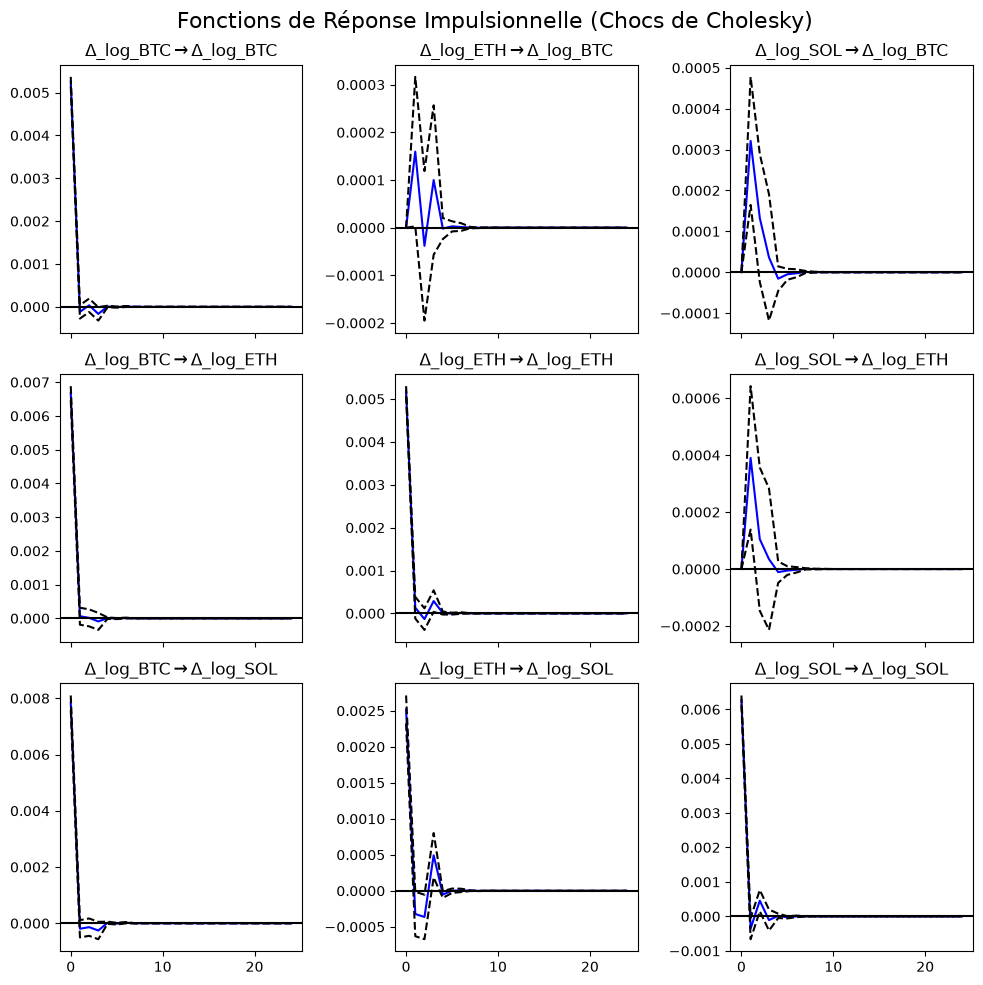

In [48]:
irf = resultats.irf(24) #analyse IRF sur 24h


fig = irf.plot(orth=True) #orthogonalized=True très important pour la décomposition de Cholesky
fig.suptitle("Fonctions de Réponse Impulsionnelle (Chocs de Cholesky)", fontsize=16)
fig.tight_layout()
plt.show()

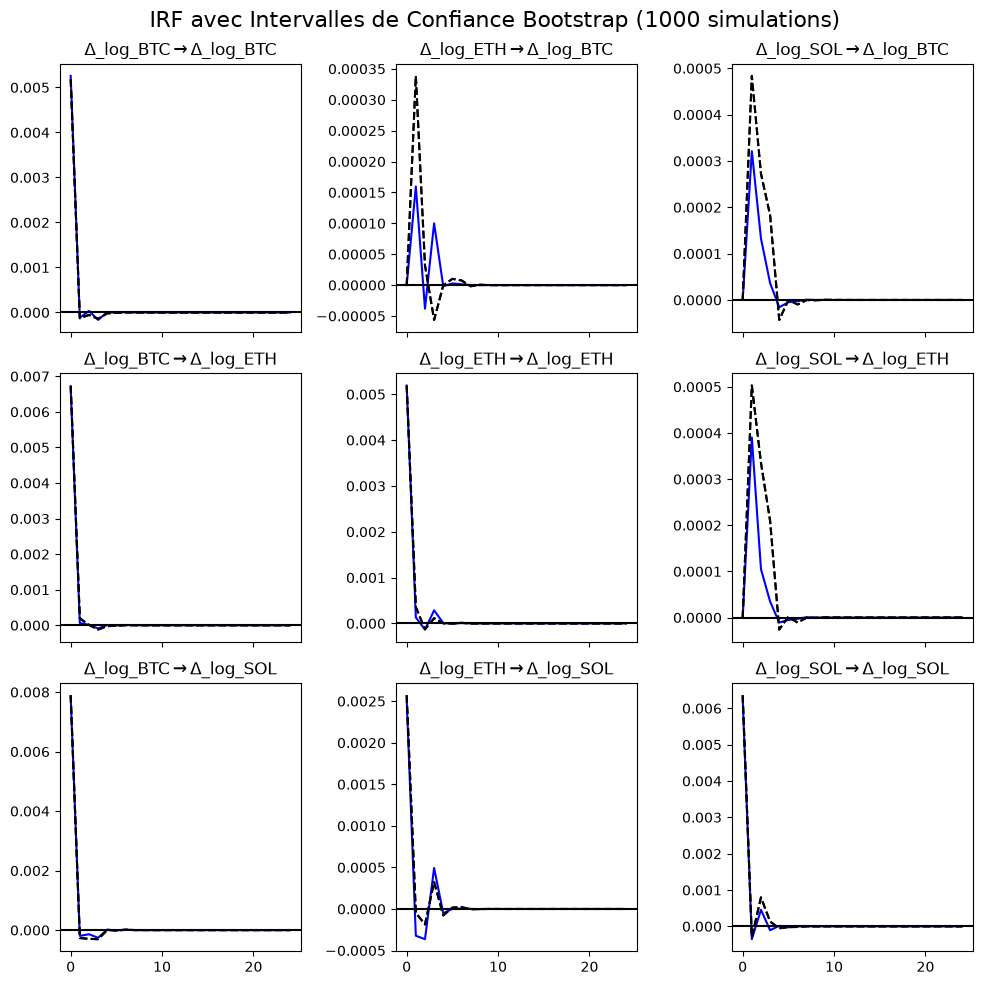

In [49]:
# Affichage avec intervalles par Bootstrap (Monte-Carlo)
fig = irf.plot(
    orth=True, 
    stderr_type='mc',  # 'mc' pour Monte-Carlo
    repl=1000,         # Nombre de simulations : 1000
    seed=42
)

fig.suptitle("IRF avec Intervalles de Confiance Bootstrap (1000 simulations)", fontsize=16)
fig.tight_layout()
plt.show()

FEVD for Δ_log_BTC
      Δ_log_BTC  Δ_log_ETH  Δ_log_SOL
0      1.000000   0.000000   0.000000
1      0.995368   0.000917   0.003715
2      0.994687   0.000969   0.004345
3      0.994288   0.001326   0.004386
4      0.994279   0.001326   0.004395
5      0.994278   0.001326   0.004396
6      0.994278   0.001326   0.004396
7      0.994278   0.001326   0.004396
8      0.994278   0.001326   0.004396
9      0.994278   0.001326   0.004396
10     0.994278   0.001326   0.004396
11     0.994278   0.001326   0.004396
12     0.994278   0.001326   0.004396
13     0.994278   0.001326   0.004396
14     0.994278   0.001326   0.004396
15     0.994278   0.001326   0.004396
16     0.994278   0.001326   0.004396
17     0.994278   0.001326   0.004396
18     0.994278   0.001326   0.004396
19     0.994278   0.001326   0.004396
20     0.994278   0.001326   0.004396
21     0.994278   0.001326   0.004396
22     0.994278   0.001326   0.004396
23     0.994278   0.001326   0.004396

FEVD for Δ_log_ETH
      Δ_log

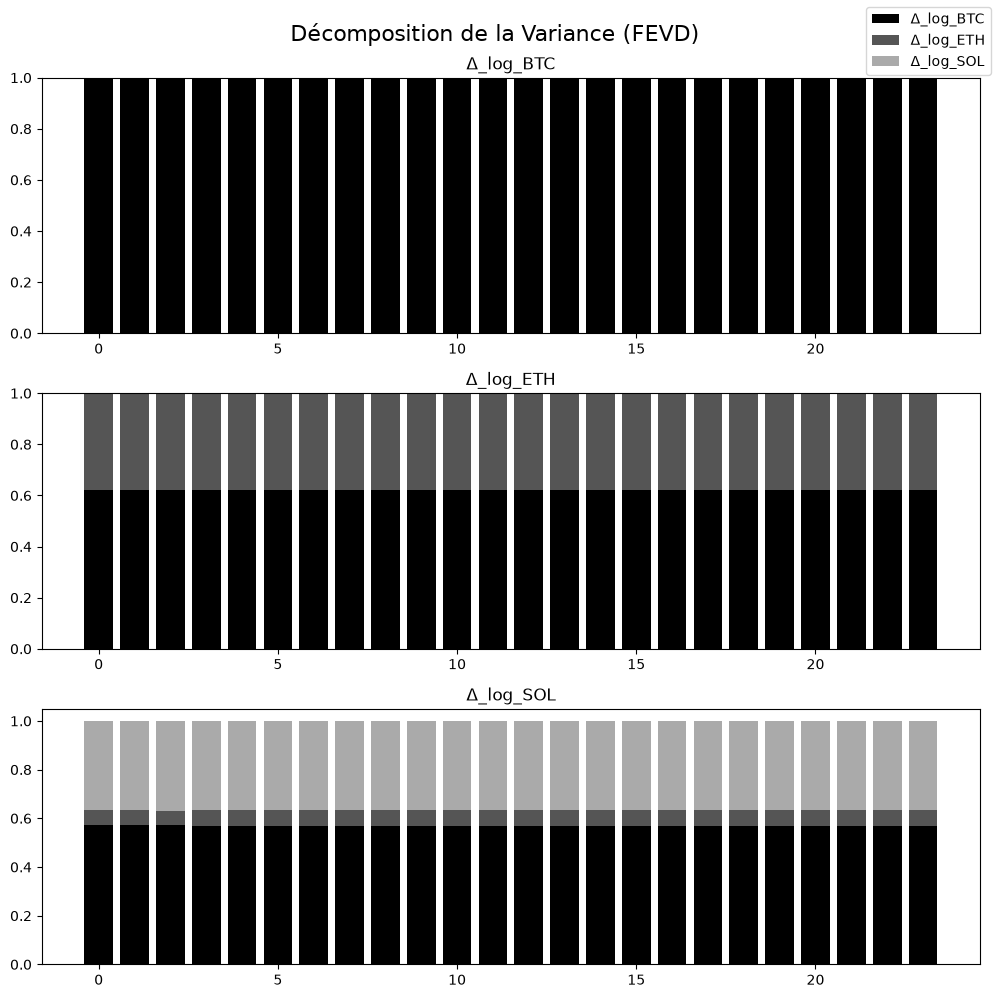

In [50]:
# Calcul de la FEVD sur 24h
fevd = resultats.fevd(24)

print(fevd.summary())

fig = fevd.plot()
fig.suptitle("Décomposition de la Variance (FEVD)", fontsize=16)
fig.tight_layout()
plt.show()